✓ Using the Pandas library, load a CSV file and perform basic data analysis tasks, such as
calculating the average of a selected column. Additionally, use Matplotlib to create
visualizations, including bar charts, scatter plots, and heatmaps, to analyze the data. Provide
insights and observations based on the analysis and visualizations.

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv("ecommerce_sales_analytics_5000.csv")

In [36]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [37]:
df.tail()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
4995,14996,9/5/2035,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74
4996,14997,9/6/2035,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47
4997,14998,9/7/2035,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06
4998,14999,9/8/2035,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38
4999,15000,9/9/2035,1214,Home,East,7,231.58,0.34,COD,5,3.9,1069.90


In [38]:
df.sample(5)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
457,10458,4/3/2023,1815,Beauty,North,6,282.88,0.07,Card,7,3.5,1578.47
1708,11709,9/5/2026,1177,Electronics,East,1,316.93,0.10,Card,4,4.0,285.24
759,10760,1/30/2024,1998,Electronics,East,7,233.36,0.34,Card,10,3.0,1078.12
4174,14175,6/6/2033,1394,Beauty,South,6,414.58,0.28,COD,11,1.9,1790.99
121,10122,5/2/2022,1791,Clothing,East,7,386.15,0.26,Card,1,1.7,2000.26


In [39]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [41]:
df.describe()

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
std,1443.520003,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219
min,10001.000000,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000


In [43]:
print(df['customer_rating'].mean())

2.9739800000000005


In [44]:
highest_gross_movie = df.loc[df['unit_price'].idxmax()]
display(highest_gross_movie)

,2701
order_id,12702
order_date,5/25/2029
customer_id,1951
product_category,Electronics
region,West
quantity,3
unit_price,599.96
discount,0.15
payment_method,COD
delivery_days,1


In [90]:
print(df['delivery_days'].mean())

6.1188


In [85]:
print(df['revenue'].sum())

5109775.74


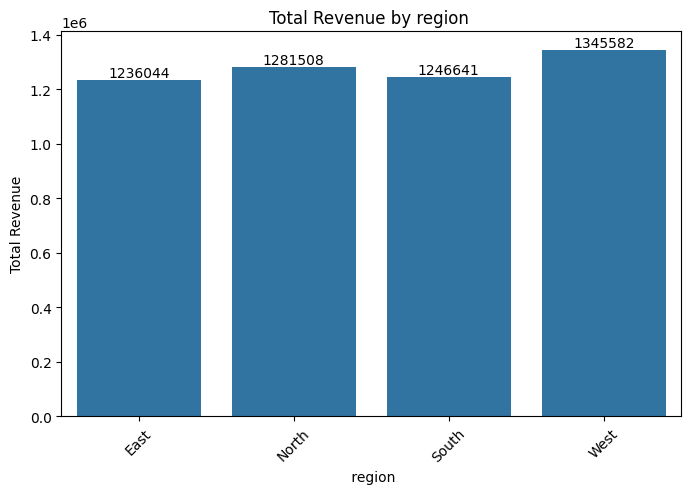

In [82]:
category_revenue = df.groupby('region')['revenue'].sum().reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(data=category_revenue, x='region', y='revenue')
for i in ax.containers:
    ax.bar_label(i, fmt='%.0f')
plt.xticks(rotation=45)
plt.xlabel(' region')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by region ')

plt.show()

Text(0.5, 1.0, 'customer_rating vs revenue')

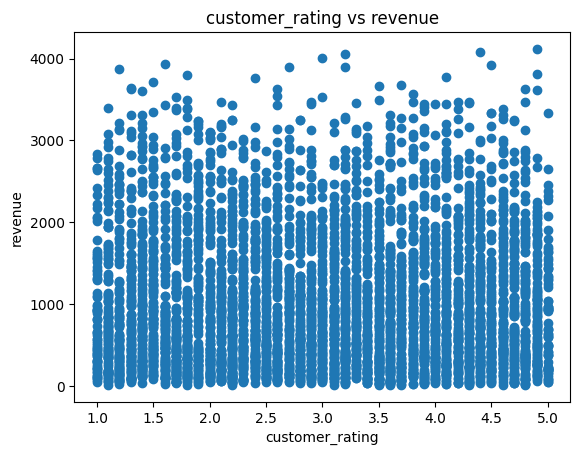

In [57]:
plt.scatter(df['customer_rating'],df['revenue'])
plt.xlabel('customer_rating')
plt.ylabel('revenue')
plt.title('customer_rating vs revenue')

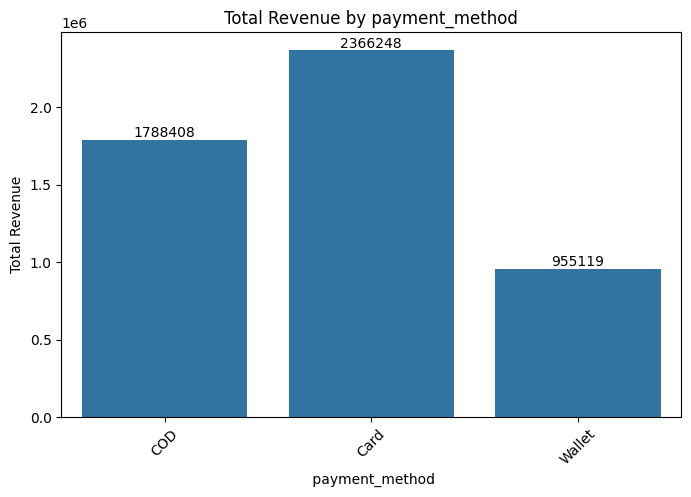

In [81]:
category_revenue = df.groupby('payment_method')['revenue'].sum().reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(data=category_revenue, x='payment_method', y='revenue')
for i in ax.containers:
    ax.bar_label(i, fmt='%.0f')
plt.xticks(rotation=45)
plt.xlabel(' payment_method')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by payment_method')

plt.show()

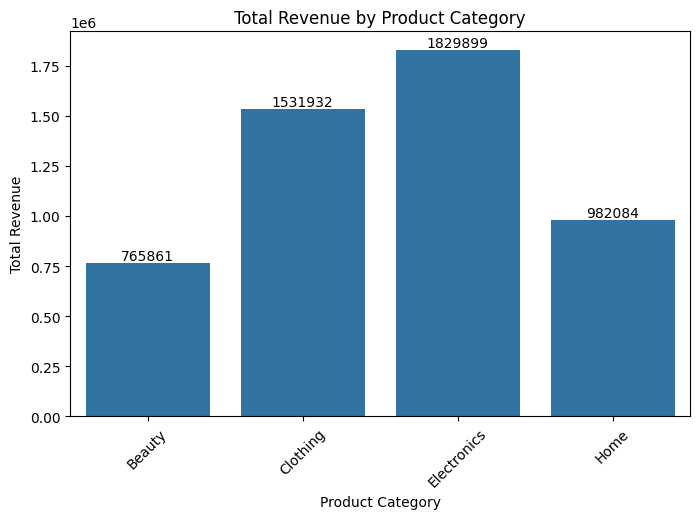

In [80]:
category_revenue = df.groupby('product_category')['revenue'].sum().reset_index()

plt.figure(figsize=(8,5))
ax = sns.barplot(data=category_revenue, x='product_category', y='revenue')
for i in ax.containers:
    ax.bar_label(i, fmt='%.0f')

plt.xticks(rotation=45)
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.title('Total Revenue by Product Category')

plt.show()

Text(0.5, 1.0, 'product_category vs quantity_ordered')

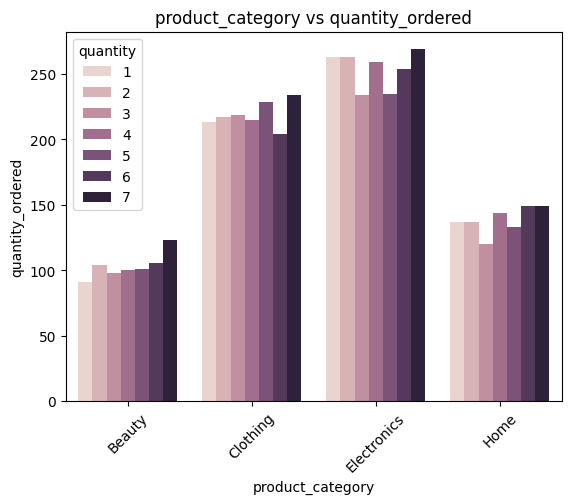

In [64]:
sns.countplot(x = 'product_category',hue = 'quantity', data=df)
plt.xticks(rotation=45)
plt.xlabel('product_category')
plt.ylabel('quantity_ordered')
plt.title('product_category vs quantity_ordered')

Text(0.5, 1.0, 'region vs quantity_ordered')

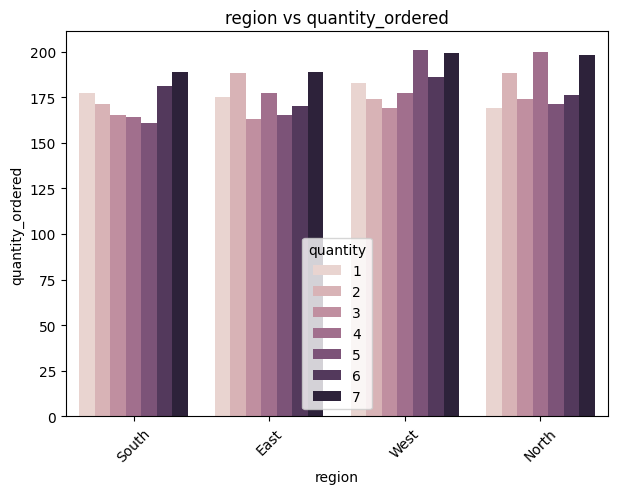

In [70]:
plt.figure(figsize= (7,5))
sns.countplot(x= 'region',hue = 'quantity' , data = df)
plt.xticks(rotation=45)
plt.xlabel('region')
plt.ylabel('quantity_ordered')
plt.title('region vs quantity_ordered')

In [45]:
df.columns


Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

Text(0.5, 1.0, 'unit_price vs discount')

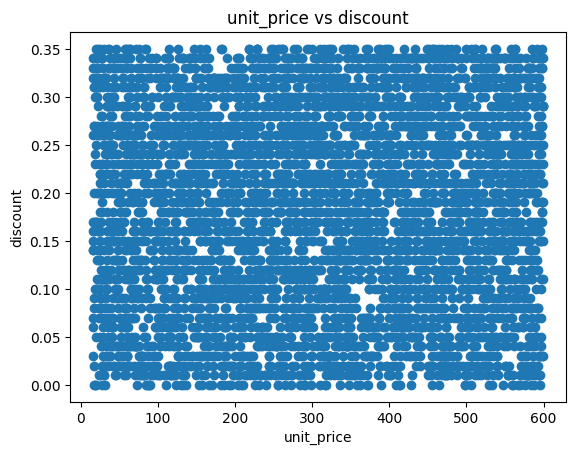

In [71]:
plt.scatter(df['unit_price'],df['discount'])
plt.xlabel('unit_price')
plt.ylabel('discount')
plt.title('unit_price vs discount')

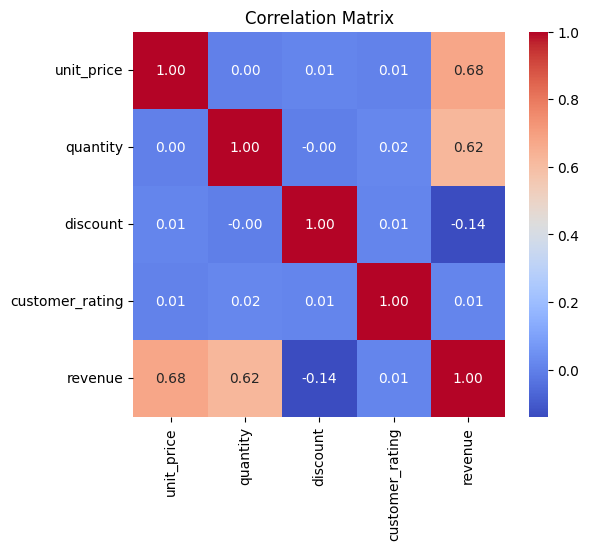

In [95]:
plt.figure(figsize=(6,5))
sns.heatmap( corr , annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

Text(0.5, 1.0, 'Total Customer Rating by Product Category')

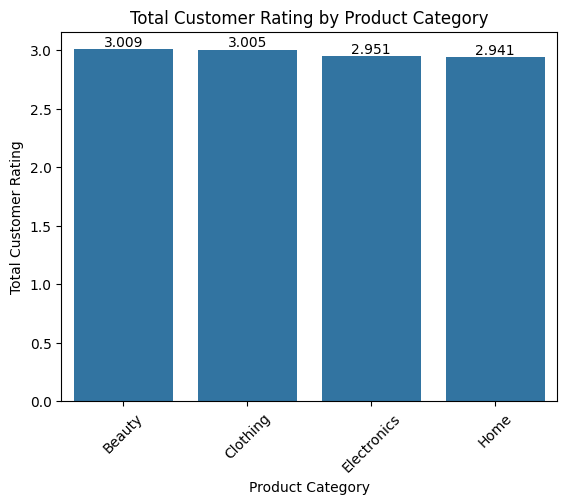

In [89]:
category = df.groupby('product_category')['customer_rating'].mean().reset_index()

ax= sns.barplot(data=category, x='product_category', y='customer_rating')
for i in ax.containers:
    ax.bar_label(i, fmt='%.3f')
plt.xticks(rotation=45)
plt.xlabel('Product Category')
plt.ylabel('Total Customer Rating')
plt.title('Total Customer Rating by Product Category')


# Insights
####total revenue generated is 5109775.74
####Electronics is the highest revenue-generating category.
####The West region contributes the most sales.
####Card payments dominate customer purchases.
####Beauty products receive the highest customer ratings.
####Average delivery time is approximately 6 days across all regions.
####Higher unit prices and larger quantities lead to increased revenue.